<a href="https://colab.research.google.com/github/muhammadabdurrehmanmaqsood/brain-tumor-classifier/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive to store the raw zip file permanently
drive.mount('/content/drive')

# 2. Create a directory in Drive to hold the project data
project_path = '/content/drive/MyDrive/brain_tumor_project/data'
os.makedirs(project_path, exist_ok=True)

Mounted at /content/drive


In [3]:
from google.colab import files

# 3. Upload the kaggle.json file
print("Upload your kaggle.json file:")
files.upload()

# 4. Move the json file to the hidden folder Kaggle expects
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json


In [4]:
# Download the dataset directly into Google Drive folder
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri -p /content/drive/MyDrive/brain_tumor_project/data

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:00<00:00, 146MB/s]



In [5]:
# Unzip the dataset from Drive into Colab's fast local storage
!unzip -q /content/drive/MyDrive/brain_tumor_project/data/brain-tumor-classification-mri.zip -d /content/dataset/

In [6]:
import os

data_dir = '/content/dataset/'

# Check the training directories and count images
print("Training Data:")
for category in os.listdir(os.path.join(data_dir, 'Training')):
    path = os.path.join(data_dir, 'Training', category)
    if os.path.isdir(path):
        print(f" - {category}: {len(os.listdir(path))} images")

Training Data:
 - glioma_tumor: 826 images
 - pituitary_tumor: 827 images
 - meningioma_tumor: 822 images
 - no_tumor: 395 images


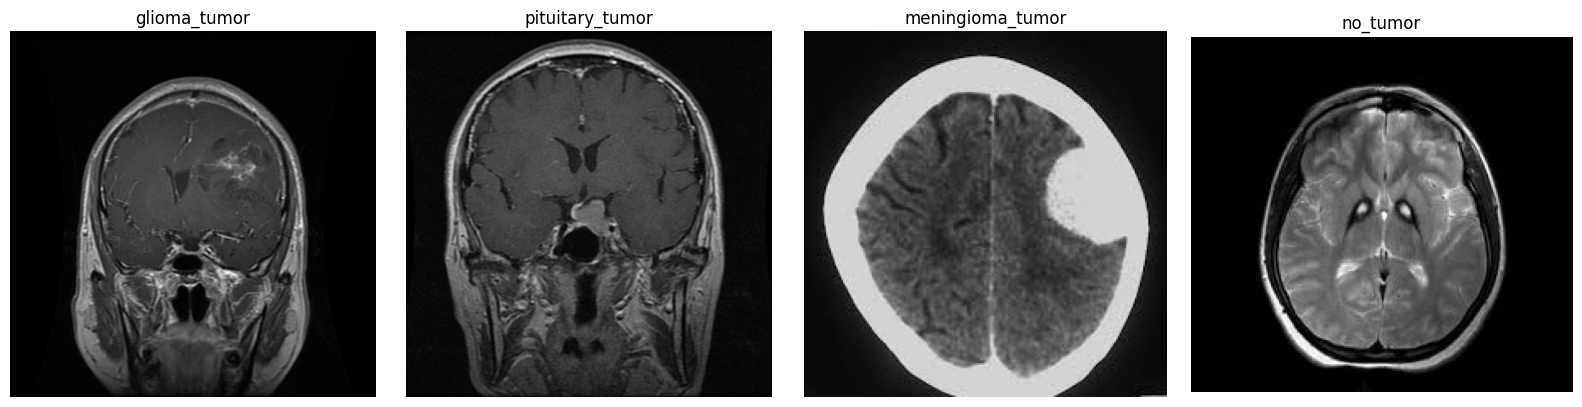

In [7]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = '/content/dataset/Training'
classes = os.listdir(train_dir)

fig, axes = plt.subplots(1, len(classes), figsize=(16, 4))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    # Pick a random image from this specific tumor class
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = mpimg.imread(img_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define the augmentation pipelines
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# The testing/validation data should NEVER be randomly flipped or rotated!
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the data directly from the unzipped folders
full_train_dataset = datasets.ImageFolder(root='/content/dataset/Training', transform=train_transforms)
test_dataset = datasets.ImageFolder(root='/content/dataset/Testing', transform=test_transforms)

# 3. Create a Validation Split (85% Train, 15% Validation)
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Set a manual seed so your split is the same every time you run the notebook
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size], generator=generator)

# 4. Package into DataLoaders (Batches of 32 images at a time)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 77
Validation batches: 14
